# Orange County Analysis

In [4]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    load_ripa_policing_data,
    load_census,
    condense_ripa_races,
    add_search_and_hit_indicators,
    policing_tables_by_year, 
    census_rollup, 
    add_per_capita_rates_by_year, 
    concat_policing_tables,
    compute_prosecution_rates,
    merge_policing_with_prosecution,
    add_disparity_metrics,
    visualization_setup,
    visualize_all_disparity_figures
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [5]:
# Load in policing data
policing = load_ripa_policing_data("orange", (2021, 2022, 2023))

In [6]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['year'] = prosecution['filed_date'].dt.year

In [7]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [8]:
# Collapse all of the non-relevant racial categories in RIPA data to "Other"
policing = condense_ripa_races(policing)

In [9]:
# Create search and hit columns
policing = add_search_and_hit_indicators(policing)

In [10]:
# Create one policing table per year
tables = policing_tables_by_year(policing, [2021, 2022, 2023])

# Roll-up the census data to be more coarse to match policing data hierarchy
# Note that Hispanic or Latino is Non-White Hispanic or Latino
census_coarse = census_rollup(census)

# Adds per-capita rates to each table
tables = add_per_capita_rates_by_year(tables, census_coarse)

# Create one big master table with all years and rates
policing_all = concat_policing_tables(tables)
policing_all

,Perceived Race,Search Rate,Hit Rate,Search Count,Hit Count,Stop Count,"Searches per 1,000","Hits per 1,000","Stops per 1,000",Year
0,Asian,0.111322,0.053381,586,281,5264,0.838192,0.401932,7.529423,2021
1,Black/African American,0.212733,0.094720,822,366,3864,16.672075,7.423333,78.370923,2021
2,Hispanic/Latino,0.220207,0.114177,9703,5031,44063,8.927766,4.629042,40.542530,2021
3,Other,0.067815,0.031602,500,233,7373,3.266437,1.522160,48.166876,2021
4,White,0.170580,0.095854,5143,2890,30150,4.290642,2.411036,25.153193,2021
5,Asian,0.063551,0.032497,1277,653,20094,1.826572,0.934026,28.741682,2022
6,Black/African American,0.217693,0.103983,2104,1005,9665,42.674022,20.383742,196.028720,2022
7,Hispanic/Latino,0.200304,0.102534,15685,8029,78306,14.431827,7.387513,72.049641,2022
8,Other,0.076360,0.035408,1033,479,13528,6.748458,3.129246,88.376712,2022
9,White,0.165253,0.092056,11277,6282,68241,9.408045,5.240874,56.931311,2022


## Prosecution Rates

In [11]:
prosecution_rates = compute_prosecution_rates(
    prosecution,
    race_col="canonical_race",
    year_col="year",
    convicted_col="was_convicted",
    enhancement_col="is_enhancement_charge"
)
prosecution_rates

,canonical_race,year,total_cases,conviction_rate,enhancement_rate
0,Asian,2021,4578,0.706204,0.107907
1,Asian,2022,4228,0.721618,0.099811
2,Asian,2023,3002,0.751499,0.081945
3,Black,2021,5250,0.729333,0.075152
4,Black,2022,6609,0.730519,0.064458
5,Black,2023,3312,0.666667,0.045592
6,Latinx,2021,50491,0.771801,0.092506
7,Latinx,2022,54525,0.771646,0.083556
8,Latinx,2023,27383,0.744294,0.076142
9,Other,2021,4653,0.617021,0.146357


# Disparity Ratios

In [12]:
# Merge policing and prosecution data into one table based on common policing race label
analysis = merge_policing_with_prosecution(
    policing_all,
    prosecution_rates,
    pros_race_col="canonical_race",
    pros_year_col="year"
)

In [13]:
# Add White-normalized ratios and a search-hit gap
analysis = add_disparity_metrics(analysis)

# Keep plots consistent across runs
analysis = visualization_setup(analysis)

# Visualizations

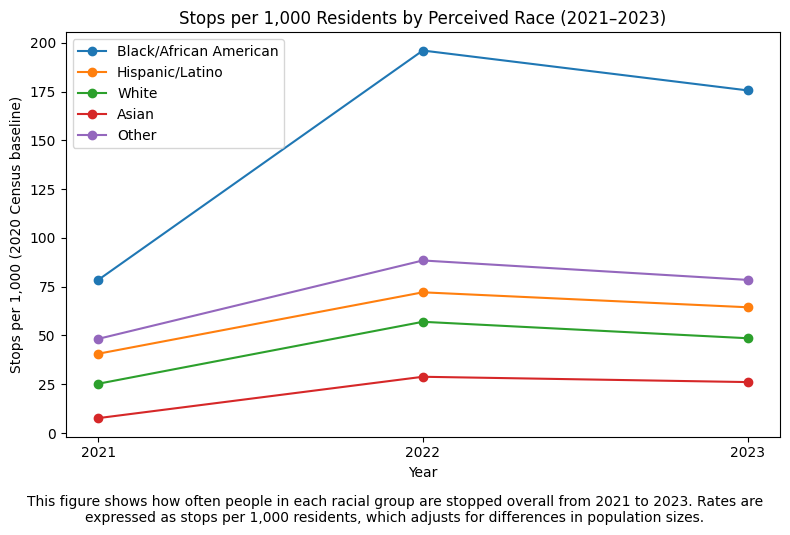

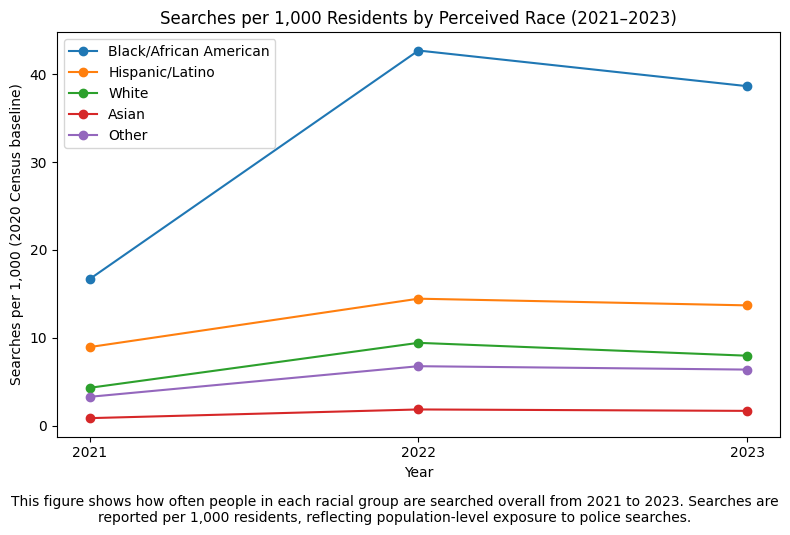

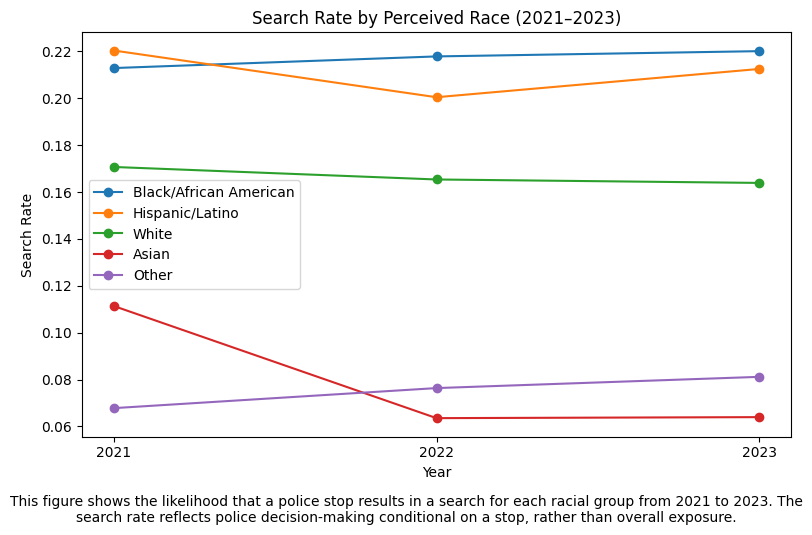

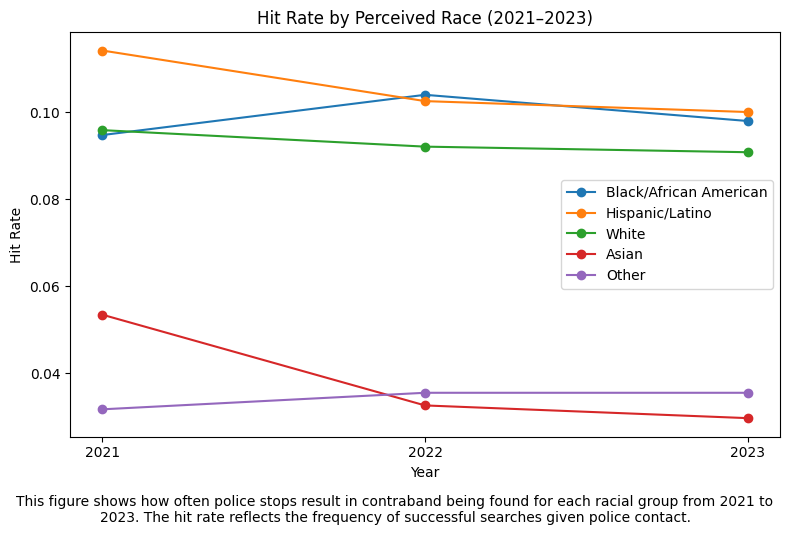

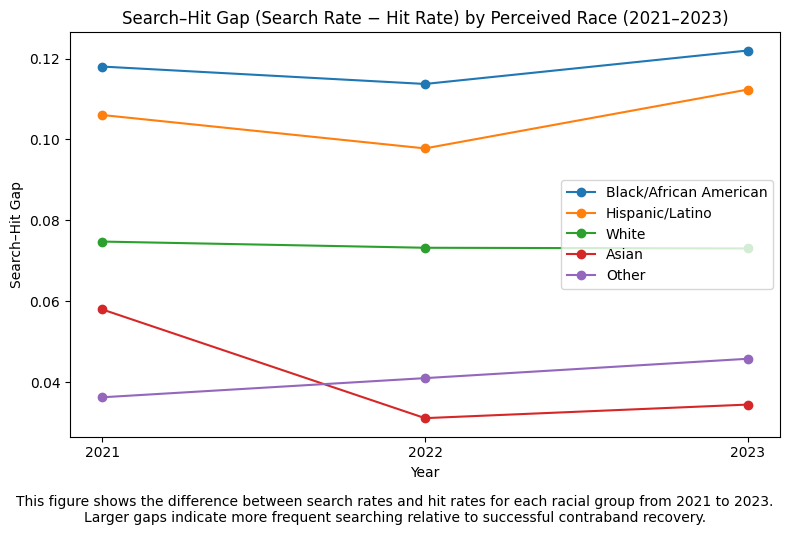

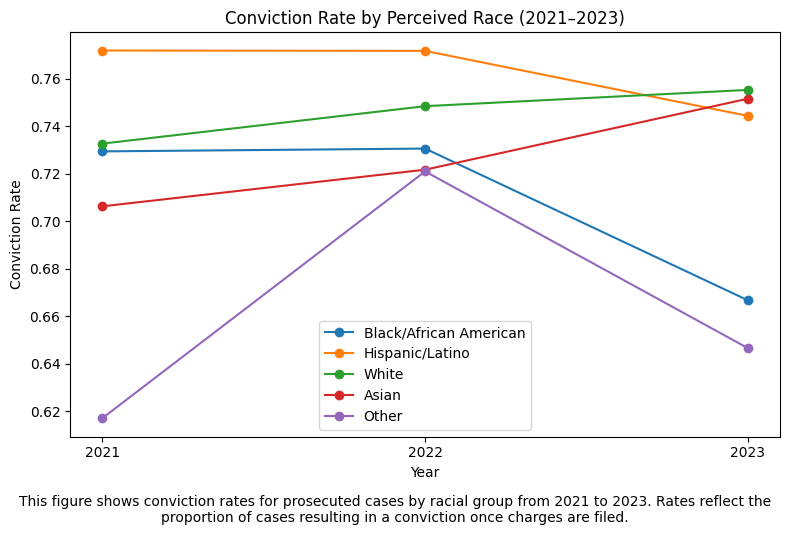

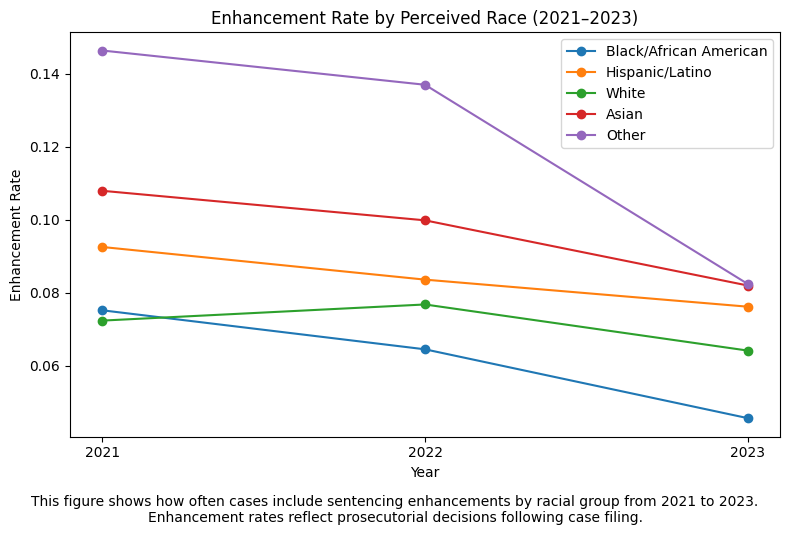

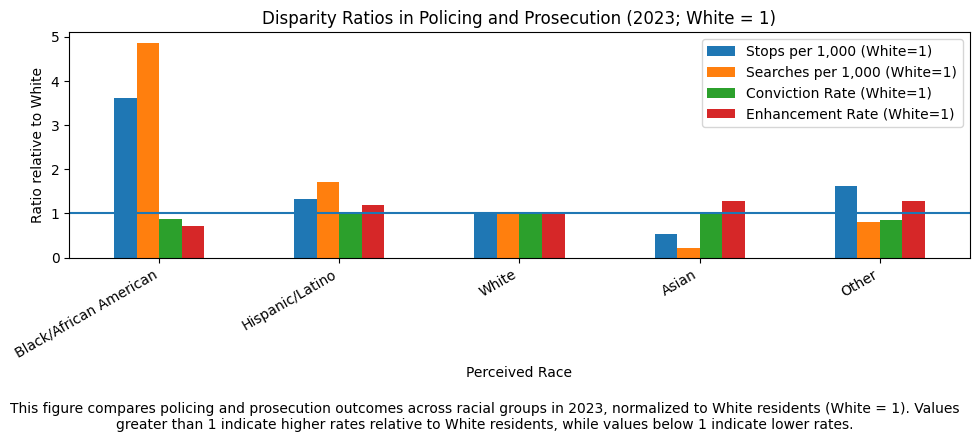

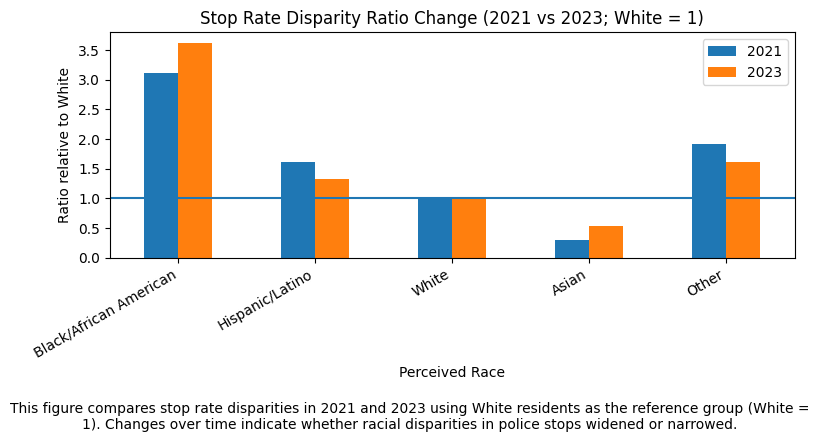

In [14]:
visualize_all_disparity_figures(analysis)